# Notebook V7 - Prédiction d'intensité (cible métier physiologique)

Cette V7 remplace la logique V6 basée sur une formule composite `intensity_score` + quantiles.

Objectif V7: définir une cible `intensite` plus explicable, à partir de règles métier fondées sur:
- `Avg_BPM`
- `Age`
- `Workout_Type`

La cible devient une politique métier explicite (zones d'intensité par type d'entraînement), plus défendable en soutenance.


## Plan
1. Imports
2. Chargement des données
3. EDA court
4. Préparation V7 + cible métier
5. Décision anti-fuite (`hr_ratio` / `hr_max_theorique`)
6. Split + entraînement RF/XGB/LR (pipelines)
7. Évaluation test
8. Validation croisée propre
9. Interprétation minimale
10. Sauvegarde artefacts (optionnel)
11. Conclusion V7


In [5]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise RuntimeError('xgboost est requis: pip install xgboost') from exc


In [6]:
BASE_DIR = Path('/home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML')
DATA_CANDIDATES = [
    BASE_DIR / 'gym_members_exercise_tracking_v2_realiste.csv',
    BASE_DIR / 'gym_members_exercise_tracking_v2.csv',
    BASE_DIR / 'gym_members_exercise_tracking.csv',
]


def resolve_data_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f'Aucun fichier trouve parmi: {candidates}')


csv_path = resolve_data_path(DATA_CANDIDATES)
print('CSV utilise :', csv_path)

df_raw = pd.read_csv(csv_path)
print('Shape brut :', df_raw.shape)
df_raw.head()


CSV utilise : /home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML/gym_members_exercise_tracking_v2.csv
Shape brut : (973, 15)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,54,Male,61.0,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,20.86
1,49,Female,63.1,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,26.96
2,30,Female,65.8,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,23.88
3,23,Male,73.5,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,25.43
4,37,Male,73.4,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,22.91


## EDA court (utile)


In [7]:
print('--- INFO ---')
df_raw.info()




--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    i

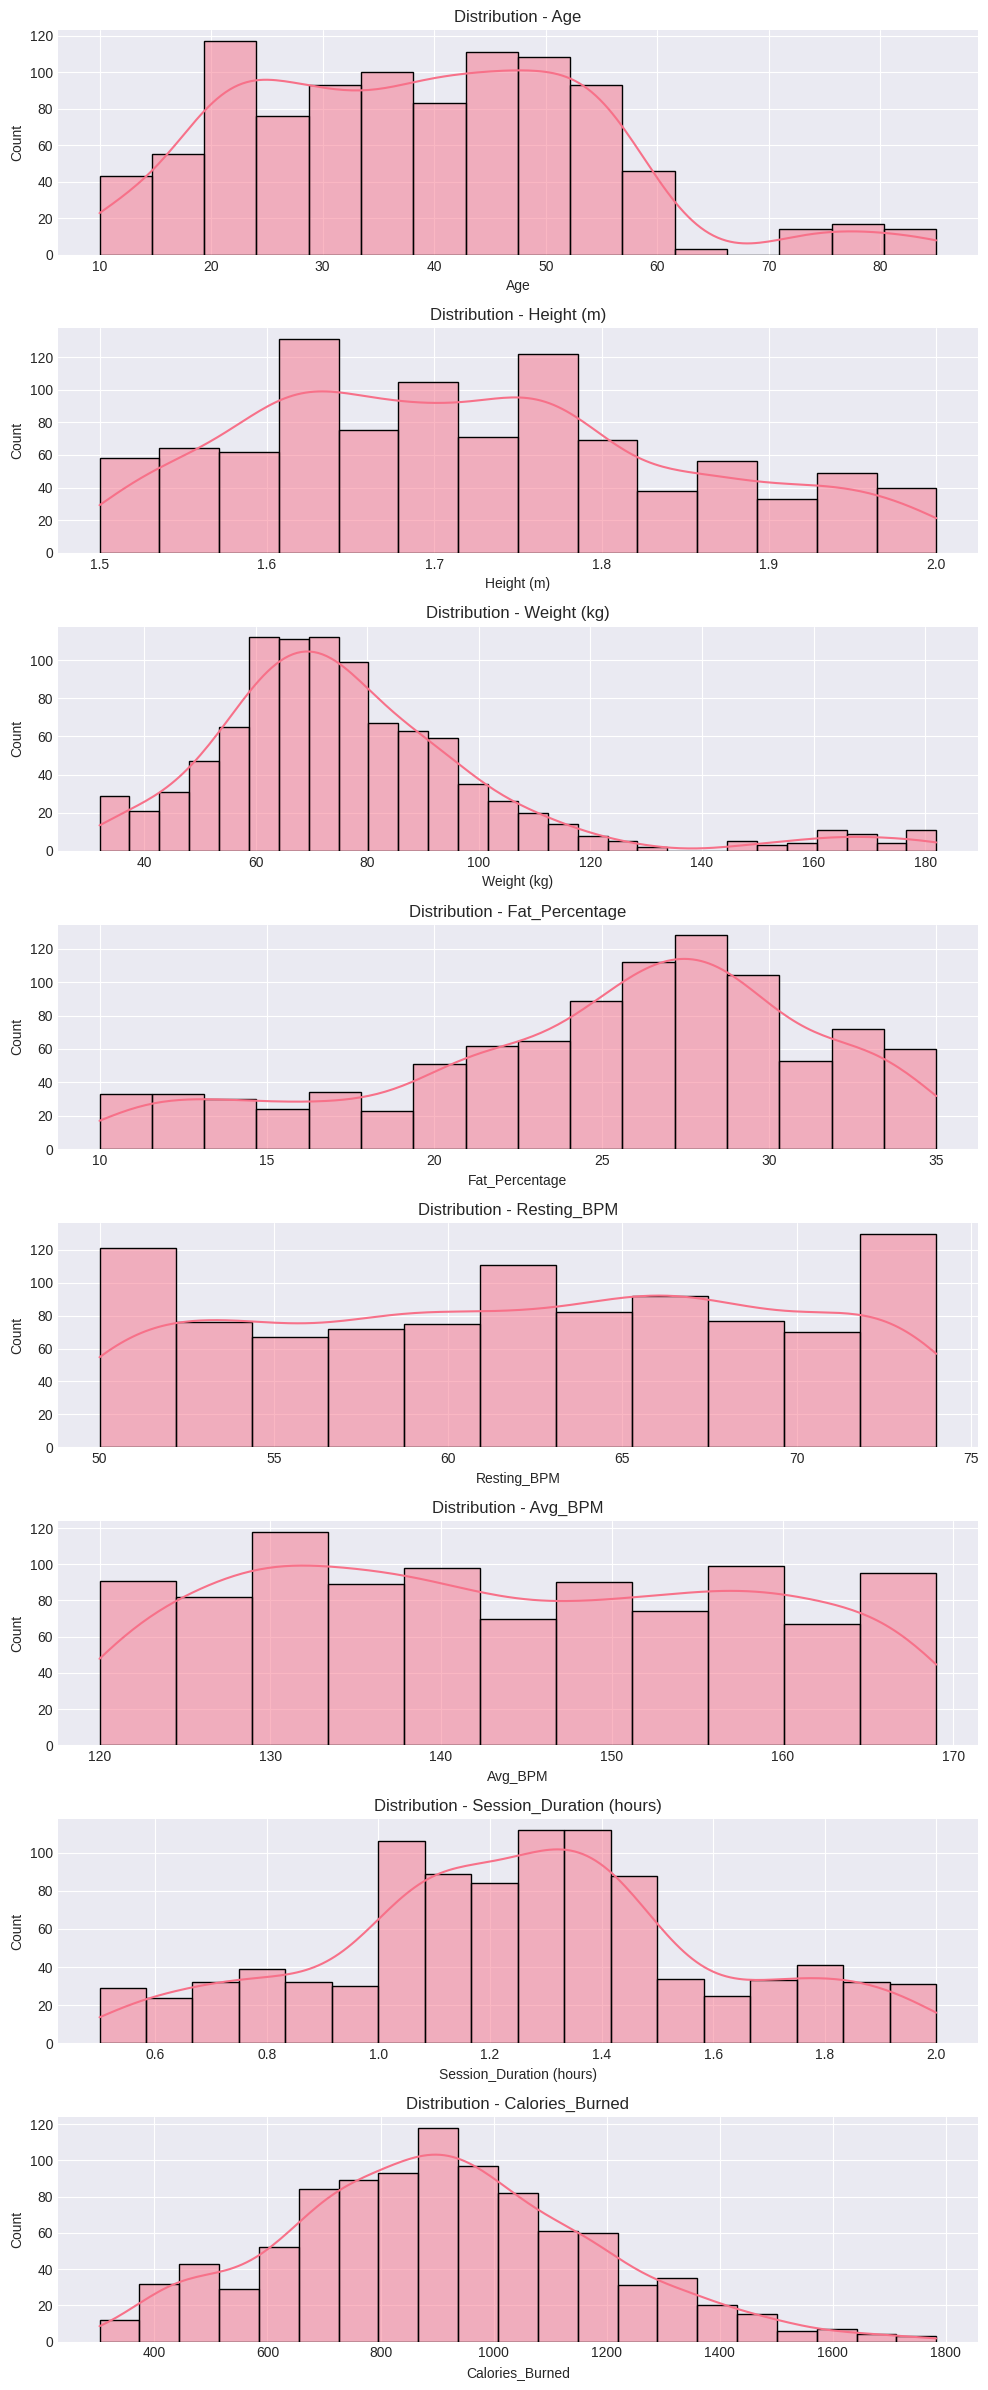

In [8]:
cols_to_plot = [
    'Age', 'Height (m)', 'Weight (kg)', 'Fat_Percentage',
    'Resting_BPM', 'Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned'
]
cols_to_plot = [c for c in cols_to_plot if c in df_raw.columns]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(10, 3 * len(cols_to_plot)))
if len(cols_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    sns.histplot(df_raw[col], kde=True, ax=ax)
    ax.set_title(f'Distribution - {col}')

plt.tight_layout()
plt.show()


In [9]:
if 'Workout_Type' in df_raw.columns:
    print('Workout_Type - valeurs uniques detectees:')
    wt_values = sorted(df_raw['Workout_Type'].dropna().astype(str).unique().tolist())
    print(wt_values)
    display(df_raw['Workout_Type'].value_counts(dropna=False))
else:
    raise ValueError("La colonne 'Workout_Type' est absente du dataset.")


Workout_Type - valeurs uniques detectees:
['Cardio', 'HIIT', 'Strength', 'Yoga']


Workout_Type
Strength    258
Cardio      255
Yoga        239
HIIT        221
Name: count, dtype: int64

## Préparation V7: nouvelle cible métier

### Pourquoi suppression de la cible V6
La V6 utilisait une formule composite (`intensity_score`) puis des quantiles. Cette approche rendait la cible fortement artificielle.

### Nouvelle logique V7
On définit `intensite` via:
- `hr_max_theorique = 220 - Age`
- `hr_ratio = Avg_BPM / hr_max_theorique`
- seuils dépendants de `Workout_Type`

Mapping demandé (avec normalisation robuste des libellés):
- **Cardio**: `<0.60 faible`, `[0.60,0.75) moyenne`, `>=0.75 elevee`
- **HIIT**: `<0.65 faible`, `[0.65,0.80) moyenne`, `>=0.80 elevee`
- **Strength / Musculation**: `<0.55 faible`, `[0.55,0.70) moyenne`, `>=0.70 elevee`
- **Autres**: règle par défaut raisonnable (`<0.60`, `[0.60,0.75)`, `>=0.75`)


In [11]:
def normalize_workout_type(x: str) -> str:
    if pd.isna(x):
        return 'other'
    s = str(x).strip().lower()

    cardio_kw = ['cardio', 'running', 'run', 'endurance', 'aerobic']
    hiit_kw = ['hiit', 'interval', 'tabata']
    strength_kw = ['strength', 'musculation', 'resistance', 'weight', 'bodybuilding']

    if any(k in s for k in cardio_kw):
        return 'cardio'
    if any(k in s for k in hiit_kw):
        return 'hiit'
    if any(k in s for k in strength_kw):
        return 'strength'
    return 'other'


def classify_intensity(hr_ratio: float, workout_type_raw: str) -> str:
    wt = normalize_workout_type(workout_type_raw)

    if wt == 'cardio':
        low, high = 0.60, 0.75
    elif wt == 'hiit':
        low, high = 0.65, 0.80
    elif wt == 'strength':
        low, high = 0.55, 0.70
    else:
        low, high = 0.60, 0.75

    if hr_ratio < low:
        return 'faible'
    if hr_ratio < high:
        return 'moyenne'
    return 'elevee'


def prepare_dataset_v7(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    required_cols = [
        'Age', 'Height (m)', 'Weight (kg)', 'Fat_Percentage',
        'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Workout_Type'
    ]
    missing = [c for c in required_cols if c not in data.columns]
    if missing:
        raise ValueError(f'Colonnes manquantes pour V7: {missing}')

    data = data[
        (data['Age'].between(16, 80))
        & (data['Height (m)'].between(1.35, 2.15))
        & (data['Weight (kg)'].between(40, 170))
        & (data['Fat_Percentage'].between(5, 55))
        & (data['Session_Duration (hours)'].between(0.3, 3.0))
        & (data['Resting_BPM'].between(35, 110))
        & (data['Avg_BPM'].between(90, 210))
    ].copy()

    data['hr_max_theorique'] = 220 - data['Age']
    data = data[data['hr_max_theorique'] > 0].copy()
    data['hr_ratio'] = data['Avg_BPM'] / data['hr_max_theorique']

    # Features dérivées utiles (non-cible)
    data['bpm_reserve'] = data['Avg_BPM'] - data['Resting_BPM']
    data['fat_mass_kg'] = data['Weight (kg)'] * (data['Fat_Percentage'] / 100.0)
    data['lean_mass_kg'] = data['Weight (kg)'] - data['fat_mass_kg']
    data['BMI_calc'] = data['Weight (kg)'] / (data['Height (m)'] ** 2)
    data['lean_mass_per_height'] = data['lean_mass_kg'] / data['Height (m)']
    data['effort_load'] = data['Session_Duration (hours)'] * (data['Avg_BPM'] / 100.0)

    data['intensite'] = [
        classify_intensity(hr_ratio, wt)
        for hr_ratio, wt in zip(data['hr_ratio'], data['Workout_Type'])
    ]

    data['Workout_Type_Normalized'] = data['Workout_Type'].apply(normalize_workout_type)

    feature_cols = [
        'Age', 'Height (m)', 'Weight (kg)', 'Fat_Percentage',
        'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)',
        'Workout_Type', 'Workout_Type_Normalized',
        'bpm_reserve', 'fat_mass_kg', 'lean_mass_kg',
        'BMI_calc', 'lean_mass_per_height', 'effort_load'
    ]

    model_df = data[feature_cols + ['intensite', 'hr_ratio', 'hr_max_theorique']].replace([np.inf, -np.inf], np.nan).dropna()
    return model_df


model_df = prepare_dataset_v7(df_raw)
print('Shape V7 :', model_df.shape)
print('Distribution intensite:')
print(model_df['intensite'].value_counts(normalize=True).round(3))
model_df.head()


Shape V7 : (889, 18)
Distribution intensite:
intensite
elevee     0.657
moyenne    0.324
faible     0.019
Name: proportion, dtype: float64


,Age,Height (m),Weight (kg),Fat_Percentage,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Workout_Type_Normalized,bpm_reserve,fat_mass_kg,lean_mass_kg,BMI_calc,lean_mass_per_height,effort_load,intensite,hr_ratio,hr_max_theorique
0,54,1.71,61.0,12.6,157,60,1.69,Yoga,other,97,7.6860,53.3140,20.861120,31.177778,2.6533,elevee,0.945783,166
1,49,1.53,63.1,33.9,151,66,1.30,HIIT,hiit,85,21.3909,41.7091,26.955444,27.260850,1.9630,elevee,0.883041,171
2,30,1.66,65.8,33.4,122,54,1.11,Cardio,cardio,68,21.9772,43.8228,23.878647,26.399277,1.3542,moyenne,0.642105,190
3,23,1.70,73.5,28.8,164,56,0.59,Strength,strength,108,21.1680,52.3320,25.432526,30.783529,0.9676,elevee,0.832487,197
4,37,1.79,73.4,29.2,158,68,0.64,Strength,strength,90,21.4328,51.9672,22.908149,29.031955,1.0112,elevee,0.863388,183


## Décision méthodologique anti-fuite (`hr_ratio`, `hr_max_theorique`)

La cible V7 est **explicitement définie** à partir de `hr_ratio` et `Workout_Type`.

Décision retenue:
- **`hr_ratio` et `hr_max_theorique` sont exclus des features d'entraînement**.
- On conserve `Age`, `Avg_BPM` et `Workout_Type` (variables source métier), car elles existent en entrée réelle.

Raison:
- inclure `hr_ratio` / `hr_max_theorique` serait une reconstruction directe trop triviale de la règle;
- les exclure rend la tâche un peu moins mécanique tout en gardant la cohérence métier.

Limite assumée:
- la cible reste une règle métier déterministe, donc les scores peuvent rester élevés.
- cette V7 est néanmoins plus défendable que V6: règle claire, explicite, physiologique, sans quantiles ad hoc.


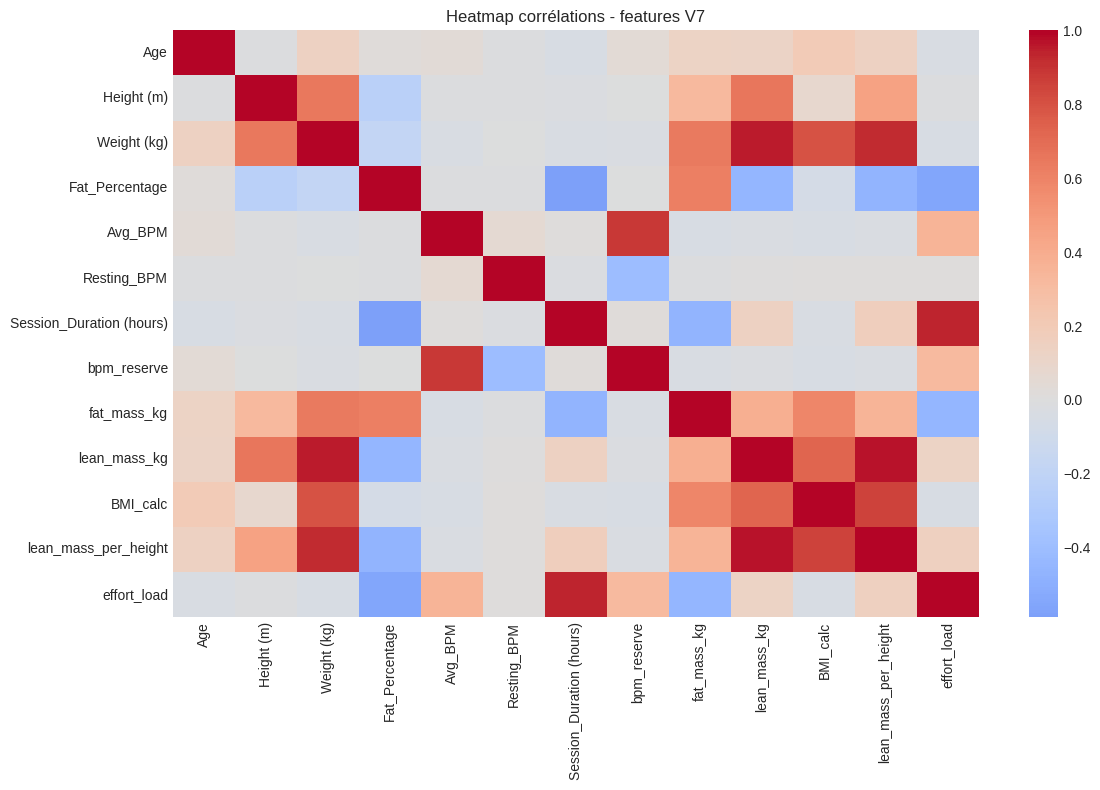

In [12]:
# Aperçu corrélations (hors variables explicitement exclues)
num_cols_corr = [
    'Age', 'Height (m)', 'Weight (kg)', 'Fat_Percentage',
    'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)',
    'bpm_reserve', 'fat_mass_kg', 'lean_mass_kg',
    'BMI_calc', 'lean_mass_per_height', 'effort_load'
]
num_cols_corr = [c for c in num_cols_corr if c in model_df.columns]

corr_v7 = model_df[num_cols_corr].corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_v7, annot=False, cmap='coolwarm', center=0)
plt.title('Heatmap corrélations - features V7')
plt.tight_layout()
plt.show()


## Split + entraînement des 3 modèles (pipelines)


In [13]:
feature_cols_train = [
    'Age', 'Height (m)', 'Weight (kg)', 'Fat_Percentage',
    'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)',
    'Workout_Type', 'Workout_Type_Normalized',
    'bpm_reserve', 'fat_mass_kg', 'lean_mass_kg',
    'BMI_calc', 'lean_mass_per_height', 'effort_load'
]

X = model_df[feature_cols_train].copy()
y = model_df['intensite'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Distribution train:')
print(y_train.value_counts(normalize=True).round(3))

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_cols),
    ]
)

rf_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1,
    )),
])

lr_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(
        solver='lbfgs',
        max_iter=3000,
        class_weight='balanced',
        random_state=42,
    )),
])

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', XGBClassifier(
        n_estimators=700,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softprob',
        num_class=len(le.classes_),
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=-1,
    )),
])

rf_pipe.fit(X_train, y_train)
lr_pipe.fit(X_train, y_train)
xgb_pipe.fit(X_train, y_train_enc)


X_train: (711, 15) | X_test: (178, 15)
Distribution train:
intensite
elevee     0.657
moyenne    0.323
faible     0.020
Name: proportion, dtype: float64


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## Évaluation test


In [14]:
def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro')
    print(f'[{name}] Accuracy: {acc:.4f} | F1 macro: {f1m:.4f}')
    print(classification_report(y_true, y_pred, digits=4))
    return {'Version': 'V7', 'Modele': name, 'Accuracy': acc, 'F1_macro': f1m}


rf_pred = rf_pipe.predict(X_test)
lr_pred = lr_pipe.predict(X_test)
xgb_pred = le.inverse_transform(xgb_pipe.predict(X_test))

res_test_v7 = [
    evaluate_classifier('RandomForest', y_test, rf_pred),
    evaluate_classifier('XGBoost', y_test, xgb_pred),
    evaluate_classifier('LogisticRegression', y_test, lr_pred),
]

results_test_v7_df = pd.DataFrame(res_test_v7).sort_values('F1_macro', ascending=False)
display(results_test_v7_df.style.format({'Accuracy': '{:.4f}', 'F1_macro': '{:.4f}'}))


[RandomForest] Accuracy: 0.9438 | F1 macro: 0.6277
              precision    recall  f1-score   support

      elevee     0.9508    0.9915    0.9707       117
      faible     0.0000    0.0000    0.0000         3
     moyenne     0.9286    0.8966    0.9123        58

    accuracy                         0.9438       178
   macro avg     0.6265    0.6293    0.6277       178
weighted avg     0.9275    0.9438    0.9353       178

[XGBoost] Accuracy: 0.9607 | F1 macro: 0.8063
              precision    recall  f1-score   support

      elevee     0.9746    0.9829    0.9787       117
      faible     1.0000    0.3333    0.5000         3
     moyenne     0.9322    0.9483    0.9402        58

    accuracy                         0.9607       178
   macro avg     0.9689    0.7548    0.8063       178
weighted avg     0.9612    0.9607    0.9581       178

[LogisticRegression] Accuracy: 0.9607 | F1 macro: 0.8895
              precision    recall  f1-score   support

      elevee     0.9912    0.

,Version,Modele,Accuracy,F1_macro
2,V7,LogisticRegression,0.9607,0.8895
1,V7,XGBoost,0.9607,0.8063
0,V7,RandomForest,0.9438,0.6277


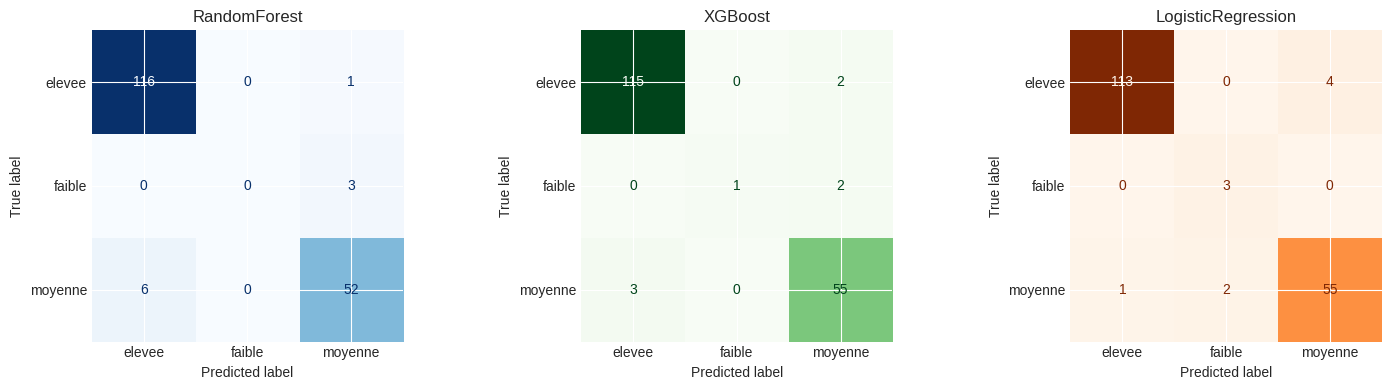

In [15]:
labels = sorted(y.unique())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name, pred, cmap in [
    (axes[0], 'RandomForest', rf_pred, 'Blues'),
    (axes[1], 'XGBoost', xgb_pred, 'Greens'),
    (axes[2], 'LogisticRegression', lr_pred, 'Oranges'),
]:
    cm = confusion_matrix(y_test, pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


## Validation croisée 5-fold (propre)

Les transformations (imputation, scaling, one-hot) sont intégrées dans les pipelines.
Cela évite les fuites dues à des transformations faites avant `cross_val_score`.


In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(rf_pipe, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
lr_cv_scores = cross_val_score(lr_pipe, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)

y_enc_full = LabelEncoder().fit_transform(y)
xgb_cv_scores = cross_val_score(xgb_pipe, X, y_enc_full, cv=cv, scoring='f1_macro', n_jobs=-1)

cv_results_v7 = pd.DataFrame({
    'Version': ['V7', 'V7', 'V7'],
    'Modele': ['RandomForest', 'XGBoost', 'LogisticRegression'],
    'F1_macro_mean': [rf_cv_scores.mean(), xgb_cv_scores.mean(), lr_cv_scores.mean()],
    'F1_macro_std': [rf_cv_scores.std(), xgb_cv_scores.std(), lr_cv_scores.std()],
}).sort_values('F1_macro_mean', ascending=False)

display(cv_results_v7.style.format({'F1_macro_mean': '{:.4f}', 'F1_macro_std': '{:.4f}'}))


,Version,Modele,F1_macro_mean,F1_macro_std
2,V7,LogisticRegression,0.8879,0.0343
1,V7,XGBoost,0.8056,0.0314
0,V7,RandomForest,0.7214,0.0825


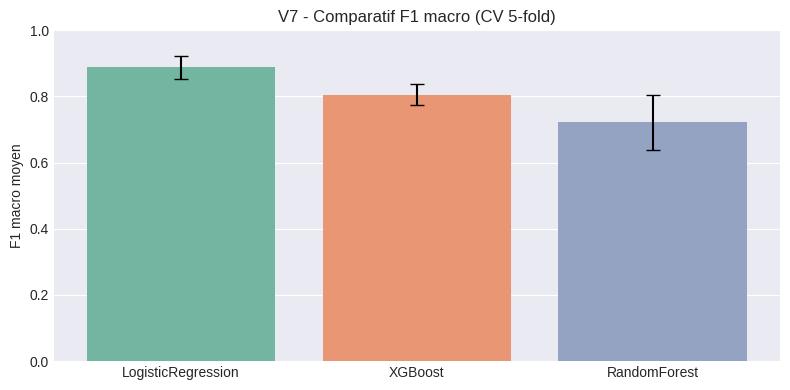

In [17]:
plt.figure(figsize=(8, 4))
sns.barplot(data=cv_results_v7, x='Modele', y='F1_macro_mean', palette='Set2')
for i, row in cv_results_v7.reset_index(drop=True).iterrows():
    plt.errorbar(i, row['F1_macro_mean'], yerr=row['F1_macro_std'], fmt='none', c='black', capsize=5)
plt.ylim(0.0, 1.0)
plt.title('V7 - Comparatif F1 macro (CV 5-fold)')
plt.xlabel('')
plt.ylabel('F1 macro moyen')
plt.tight_layout()
plt.show()


## Commentaire rapide des résultats

- Lire en priorité le **F1 macro CV** (moyenne + écart-type).
- Comparer ensuite avec le test hold-out pour vérifier la cohérence.
- Si les scores V7 baissent vs V6, ce n'est pas forcément négatif: la cible V7 est plus explicable et plus crédible méthodologiquement.


## Sauvegarde artefacts V7 (optionnel)


In [ ]:
# Décommente pour sauvegarder les modèles V7
# import joblib
# artifacts_dir = BASE_DIR / 'artifacts_intensite_v7'
# artifacts_dir.mkdir(exist_ok=True)
#
# joblib.dump(rf_pipe, artifacts_dir / 'rf_v7_pipeline.joblib')
# joblib.dump(xgb_pipe, artifacts_dir / 'xgb_v7_pipeline.joblib')
# joblib.dump(lr_pipe, artifacts_dir / 'lr_v7_pipeline.joblib')
# joblib.dump(le, artifacts_dir / 'label_encoder_xgb_v7.joblib')
# print('Artefacts V7 sauvegardés dans', artifacts_dir)


## Conclusion V7

### Ce que V7 améliore par rapport à V6
- suppression de la cible V6 basée sur formule composite + quantiles;
- nouvelle cible métier explicite, basée sur `Avg_BPM`, `Age`, `Workout_Type`;
- mapping robuste des types d'entraînement;
- validation croisée plus rigoureuse via pipelines.

### Pourquoi des scores potentiellement plus faibles peuvent être plus crédibles
- le protocole est moins "optimiste" (préprocessing en CV, pas de quantiles ad hoc);
- l'objectif est la défendabilité méthodologique, pas l'optimisation artificielle.

### Pourquoi cette version est plus défendable en soutenance
- règle de définition cible simple, physiologique et expliquable;
- hypothèses explicites;
- limites clairement reconnues (cible encore déterministe, basée sur politique métier).
